In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from turbos.sim.p3d.p3d_2 import P3D
import matplotlib.pyplot as plt

In [4]:
run = P3D(
    "/archive/tulasi/MEGARUNS_DATA_SUBSET/149p6",
    filenum="000",
)
#419
ds = run.load_xarray(419, variables=['B'])
print(ds)

<xarray.Dataset> Size: 201MB
Dimensions:  (x: 4096, y: 4096, c: 3)
Coordinates:
  * x        (x) float64 33kB 0.0 0.03652 0.07305 0.1096 ... 149.5 149.5 149.6
  * y        (y) float64 33kB 0.0 0.03652 0.07305 0.1096 ... 149.5 149.5 149.6
  * c        (c) <U1 12B 'x' 'y' 'z'
Data variables:
    B        (x, y, c) float32 201MB -0.1022 0.08558 1.02 ... 0.0901 1.021
Attributes:
    time:      209.5
    run:       149p6
    snapshot:  419
    format:    hdf5


In [21]:
from turbos.filter import kfilter
B_F = kfilter(ds['B'], 13)

In [22]:
from turbos.spectrum import energy_spectrum

B_es = energy_spectrum(ds['B'])
B_es_F = energy_spectrum(B_F)
print(B_es)
print(B_es_F)

<xarray.DataArray 'E' (k: 2897)> Size: 12kB
array([2.7332209e-20, 6.6471314e-03, 3.1693709e-01, ..., 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00], shape=(2897,), dtype=float32)
Coordinates:
  * k        (k) float64 23kB 0.021 0.063 0.105 0.147 ... 121.6 121.6 121.7
Attributes:
    long_name:      isotropic energy spectrum
    spatial_dims:   ('x', 'y')
    subtract_mean:  True
    energy_factor:  0.5
<xarray.DataArray 'E' (k: 2897)> Size: 12kB
array([1.9568570e-05, 6.6471314e-03, 3.1693700e-01, ..., 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00], shape=(2897,), dtype=float32)
Coordinates:
  * k        (k) float64 23kB 0.021 0.063 0.105 0.147 ... 121.6 121.6 121.7
Attributes:
    long_name:      isotropic energy spectrum
    spatial_dims:   ('x', 'y')
    subtract_mean:  True
    energy_factor:  0.5


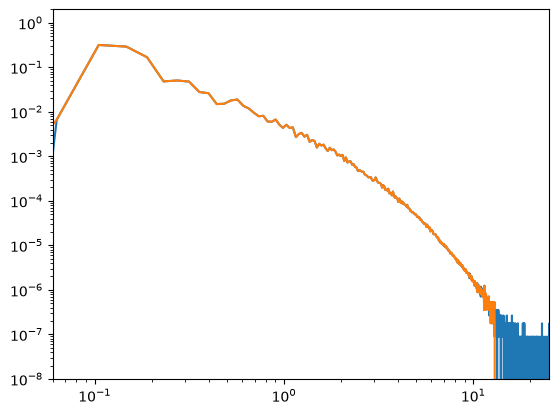

In [25]:
plt.loglog(B_es['k'].values, B_es)
plt.loglog(B_es_F['k'].values, B_es_F)
plt.xlim(6e-2, 25)
plt.ylim(1e-8, 2)
plt.show()

In [42]:
import numpy as np
E_spec = np.trapezoid(
    B_es.values,
    B_es["k"].values,
)

dB = ds["B"] - ds["B"].mean(("x", "y"))
E_sum = 0.5 * np.mean(
    np.sum(dB.values**2, axis=-1)
)

print(E_spec)
print(E_sum)

0.05056415715578645
0.0505657
